# <u> <center> Tesla Stock Price Prediction Project

## Skills take-away : Basic Python, Data Visualization, Data Cleaning, EDA, NLP, Deep Learning (SimpleRNN and LSTM), TimeSeries (ARIMA)
## Domain :  Financial Services
## Algorithm Type :  Regression 

| Model     | Algorithm Type                     | Why                                                     |
| --------- | ---------------------------------- | ------------------------------------------------------- |
| **ARIMA** | Statistical Time Series Regression | Predicts continuous values using past prices            |
| **RNN**   | Deep Learning Regression           | Learns sequential numeric patterns                      |
| **LSTM**  | Deep Learning Regression           | Captures long-term dependencies for numeric forecasting |

## Author : Shyam SR 

## GitHUB link :  https://github.com/Shyamsr1/TeslaPricePrediction

# Problem Statement : 
- Stock prices are sequential, volatile, and non-linear, making traditional models insufficient for accurate multi-day forecasting.
- The challenge is to build and compare deep learning time-series regression models (RNN, LSTM) to reliably predict Tesla’s closing price for short-term horizons (1, 5, 10 days).
# Business Problem : 
- Accurate stock price forecasting enables data-driven trading, investment decisions, and risk management instead of intuition-based decisions.
- The solution helps investors and businesses anticipate price trends, optimize portfolios, and improve financial planning using AI-driven insights.


# Libraries and Data Import

In [6]:
# =========================================
# Tesla Stock Price Prediction (Close)
# SimpleRNN vs LSTM vs ARIMA (1/5/10 days)
# GridSearchCV for DL Hyperparameter Tuning
# =========================================

# -----------------------------
# 0. Install (if needed)
# -----------------------------
# !pip install -q scikeras tensorflow statsmodels matplotlib pandas numpy scikit-learn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from scikeras.wrappers import KerasRegressor

from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

DATA_PATH = "data/TSLA.csv"  # provided


# Data Load and Analysis

In [7]:
# -----------------------------
# 1. Load Dataset
# -----------------------------
df = pd.read_csv(DATA_PATH)

print(df.shape)
display(df.head())

# Convert date and sort
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Set Date index (useful for time-series)
df = df.set_index("Date")
display(df.tail())

print("\nMissing values:\n", df.isna().sum())


(2416, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700
2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300
2020-02-03,673.690002,786.140015,673.520020,780.000000,780.000000,47065000



Missing values:
 Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [8]:
# Check for all information uploaded 
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2416 entries, 2010-06-29 to 2020-02-03
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2416 non-null   float64
 1   High       2416 non-null   float64
 2   Low        2416 non-null   float64
 3   Close      2416 non-null   float64
 4   Adj Close  2416 non-null   float64
 5   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 132.1 KB


# EDA (Exploratory Data Analysis) 

In [21]:
# -----------------------------
# 2. EDA + Visualization (9 visuals) + Hypothesis Testing (3 tests)
#  - 3 Univariate + 3 Bivariate + 3 Multivariate
#  - For each graph: why chosen + 3 insights printed
#  - For each hypothesis test: why chosen + H0 + final decision
# -----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.tsa.stattools import adfuller

# ---------- Setup ----------
target_col = "Close"  # required
df = df.sort_index().copy()

# keep only needed numeric cols if present
base_cols = [c for c in ["Open", "High", "Low", "Close", "Volume"] if c in df.columns]
if target_col not in df.columns:
    raise ValueError(f"'{target_col}' not found in df.columns")

series = df[target_col].astype(float).copy()

# Feature engineering for EDA
df["Return"] = series.pct_change()
df["LogReturn"] = np.log(series).diff()
df["AbsReturn"] = df["Return"].abs()
df["MA20"] = series.rolling(20).mean()
df["MA50"] = series.rolling(50).mean()
df["Volatility20"] = df["Return"].rolling(20).std()  # rolling daily volatility proxy
df["RangeHL"] = (df["High"] - df["Low"]) if ("High" in df.columns and "Low" in df.columns) else np.nan
df["DayOfWeek"] = df.index.dayofweek if hasattr(df.index, "dayofweek") else np.nan  # 0=Mon..6=Sun

# Clean rows for analyses
eda_df = df.dropna(subset=["Return", "LogReturn", "AbsReturn", "MA20", "MA50", "Volatility20"])
returns = eda_df["Return"]
log_returns = eda_df["LogReturn"]

# Helper for consistent prints
def print_insights(title, insights):
    print("\n" + "=" * 80)
    print(title)
    for i, s in enumerate(insights, 1):
        print(f"{i}. {s}")



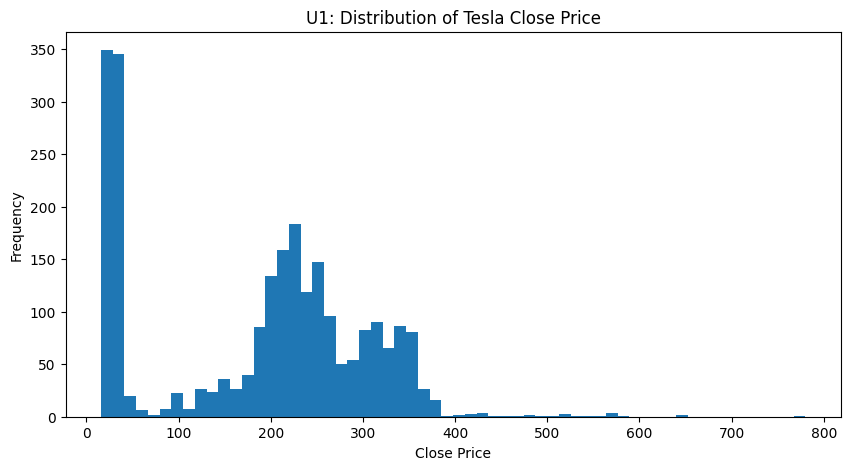


U1 Insights (Close Price Histogram)
1. Price distribution is typically non-normal for equities (often skewed / heavy-tailed).
2. Multiple peaks can indicate different market regimes (bull vs bear phases).
3. Wide spread suggests high variability → forecasting models must handle non-stationary scale.


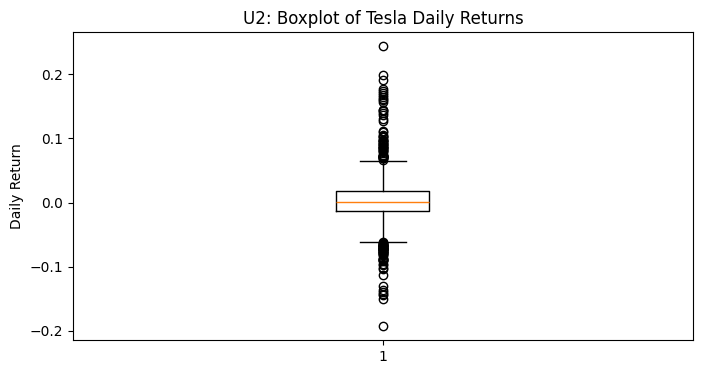


U2 Insights (Return Boxplot)
1. Outliers indicate occasional extreme moves (news/earnings-driven volatility).
2. Median near zero is common; mean may still differ due to skew/outliers.
3. Interquartile range reflects typical daily risk; compare later with rolling volatility.


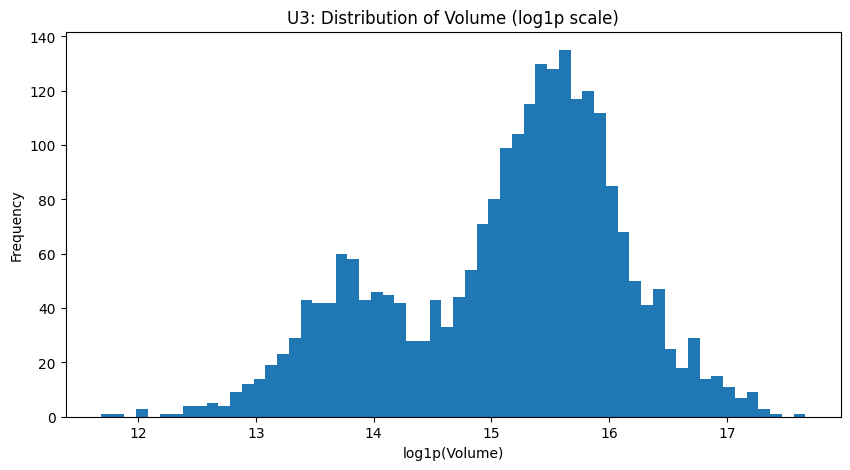


U3 Insights (Volume Histogram - log scale)
1. Volume often has a long tail; log transform makes spikes interpretable.
2. High-volume days may align with major price moves or events.
3. If volume regime shifts exist, it may impact return/volatility dynamics.


In [22]:
# =========================
# UNIVARIATE (3 visuals)
# =========================

# (U1) Histogram of Close Prices
# Why chosen: shows distribution shape (skewness, multimodality) and typical price zones.
plt.figure(figsize=(10, 5))
plt.hist(series.dropna(), bins=60)
plt.title("U1: Distribution of Tesla Close Price")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()

print_insights(
    "U1 Insights (Close Price Histogram)",
    [
        "Price distribution is typically non-normal for equities (often skewed / heavy-tailed).",
        "Multiple peaks can indicate different market regimes (bull vs bear phases).",
        "Wide spread suggests high variability → forecasting models must handle non-stationary scale.",
    ],
)

# (U2) Boxplot of Daily Returns
# Why chosen: quickly reveals outliers, median, and return dispersion (risk).
plt.figure(figsize=(8, 4))
plt.boxplot(returns.values, vert=True)
plt.title("U2: Boxplot of Tesla Daily Returns")
plt.ylabel("Daily Return")
plt.show()

print_insights(
    "U2 Insights (Return Boxplot)",
    [
        "Outliers indicate occasional extreme moves (news/earnings-driven volatility).",
        "Median near zero is common; mean may still differ due to skew/outliers.",
        "Interquartile range reflects typical daily risk; compare later with rolling volatility.",
    ],
)

# (U3) Volume Distribution (log-scaled)
# Why chosen: volume is usually heavy-tailed; log scale makes structure visible.
if "Volume" in df.columns:
    vol = df["Volume"].dropna().astype(float)
    plt.figure(figsize=(10, 5))
    plt.hist(np.log1p(vol), bins=60)
    plt.title("U3: Distribution of Volume (log1p scale)")
    plt.xlabel("log1p(Volume)")
    plt.ylabel("Frequency")
    plt.show()

    print_insights(
        "U3 Insights (Volume Histogram - log scale)",
        [
            "Volume often has a long tail; log transform makes spikes interpretable.",
            "High-volume days may align with major price moves or events.",
            "If volume regime shifts exist, it may impact return/volatility dynamics.",
        ],
    )
else:
    print("\n[U3 skipped] 'Volume' column not found in df.")



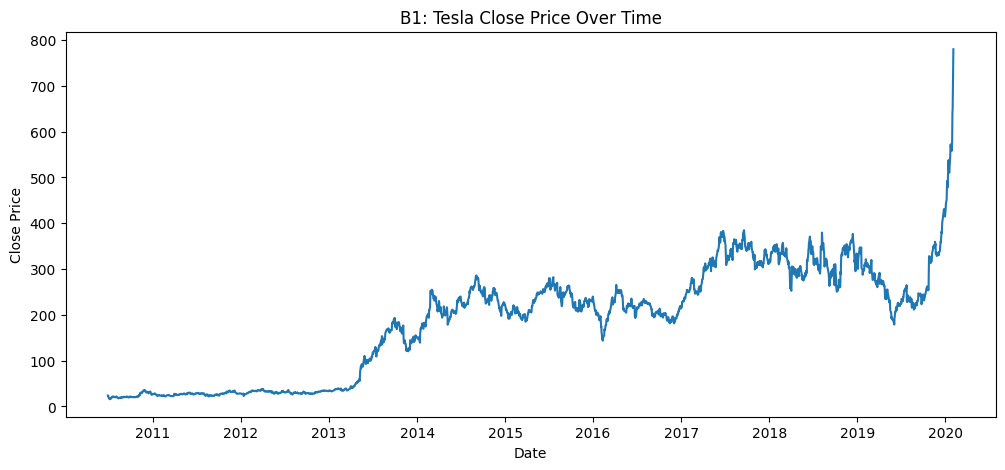


B1 Insights (Close Over Time)
1. Trends/regime changes indicate non-stationarity → differencing/returns often needed.
2. Large swings suggest volatility clustering (periods of calm vs turbulence).
3. Structural breaks can degrade ARIMA performance if not handled (windowing/rolling fit).


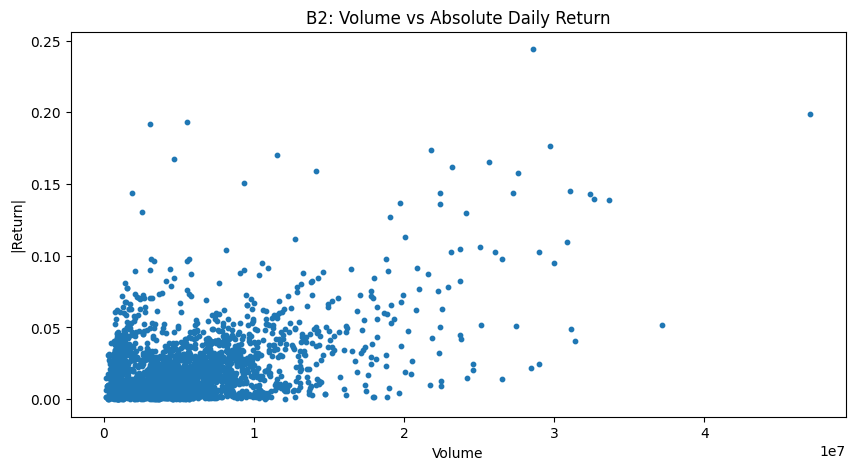


B2 Insights (Volume vs |Return|)
1. A positive pattern suggests high volume days often come with larger moves.
2. Weak pattern implies volume may not be a strong predictor of move magnitude alone.
3. Nonlinear clusters may indicate event-driven bursts rather than steady relationship.


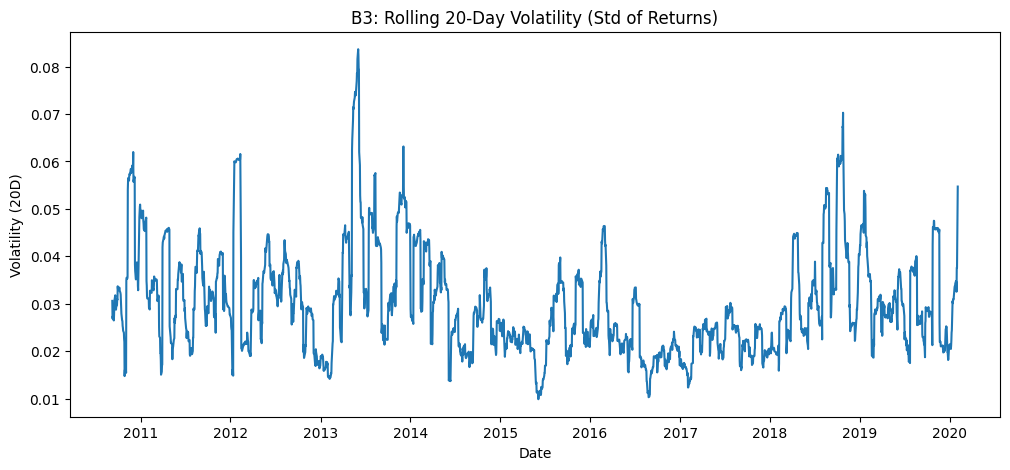


B3 Insights (Rolling Volatility)
1. Spikes confirm volatility clustering (common in stocks).
2. High-volatility windows can distort model residuals if model assumes constant variance.
3. Can guide splitting train/test by regime or using volatility-aware models/features.


In [23]:
# =========================
# BIVARIATE (3 visuals)
# =========================

# (B1) Close Price Over Time (time vs close)
# Why chosen: best to see trend, regime shifts, structural breaks (time-series nature).
plt.figure(figsize=(12, 5))
plt.plot(series)
plt.title("B1: Tesla Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

print_insights(
    "B1 Insights (Close Over Time)",
    [
        "Trends/regime changes indicate non-stationarity → differencing/returns often needed.",
        "Large swings suggest volatility clustering (periods of calm vs turbulence).",
        "Structural breaks can degrade ARIMA performance if not handled (windowing/rolling fit).",
    ],
)

# (B2) Scatter: Volume vs Absolute Returns (if volume exists)
# Why chosen: checks whether high activity coincides with large price movements (liquidity/attention effect).
if "Volume" in df.columns:
    tmp = eda_df.dropna(subset=["Volume", "AbsReturn"])
    plt.figure(figsize=(10, 5))
    plt.scatter(tmp["Volume"], tmp["AbsReturn"], s=10)
    plt.title("B2: Volume vs Absolute Daily Return")
    plt.xlabel("Volume")
    plt.ylabel("|Return|")
    plt.show()

    print_insights(
        "B2 Insights (Volume vs |Return|)",
        [
            "A positive pattern suggests high volume days often come with larger moves.",
            "Weak pattern implies volume may not be a strong predictor of move magnitude alone.",
            "Nonlinear clusters may indicate event-driven bursts rather than steady relationship.",
        ],
    )
else:
    print("\n[B2 skipped] 'Volume' column not found in df.")

# (B3) Rolling Volatility vs Time
# Why chosen: visualizes volatility clustering; key property for finance time series.
plt.figure(figsize=(12, 5))
plt.plot(eda_df["Volatility20"])
plt.title("B3: Rolling 20-Day Volatility (Std of Returns)")
plt.xlabel("Date")
plt.ylabel("Volatility (20D)")
plt.show()

print_insights(
    "B3 Insights (Rolling Volatility)",
    [
        "Spikes confirm volatility clustering (common in stocks).",
        "High-volatility windows can distort model residuals if model assumes constant variance.",
        "Can guide splitting train/test by regime or using volatility-aware models/features.",
    ],
)



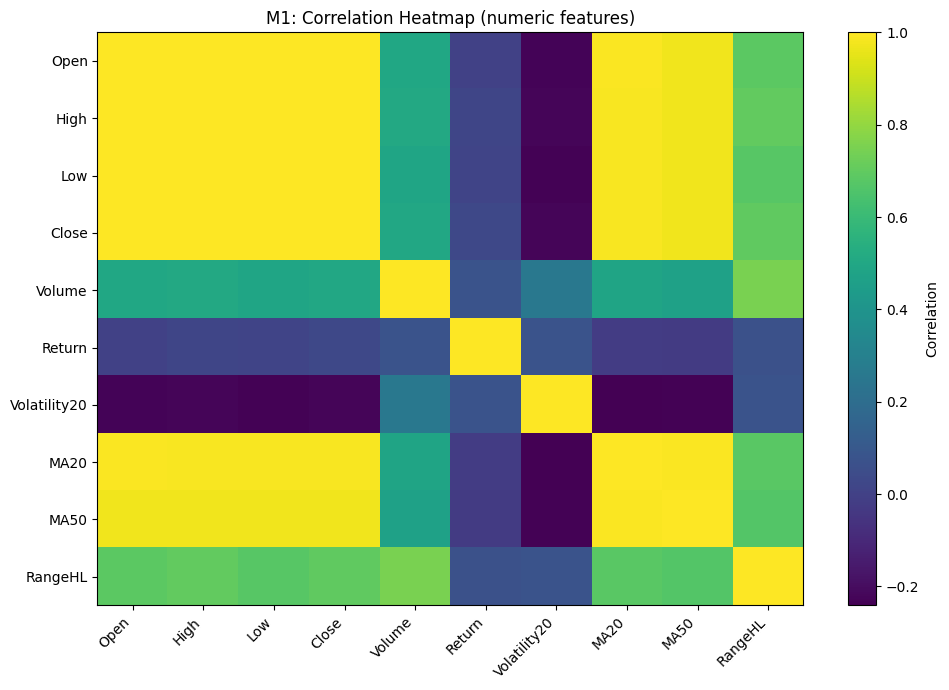


M1 Insights (Correlation Heatmap)
1. OHLC are usually highly correlated → multicollinearity; avoid using all together blindly.
2. Returns often show low correlation with raw prices → better to model returns/changes.
3. Strong correlations can guide feature pruning or regularization choices.


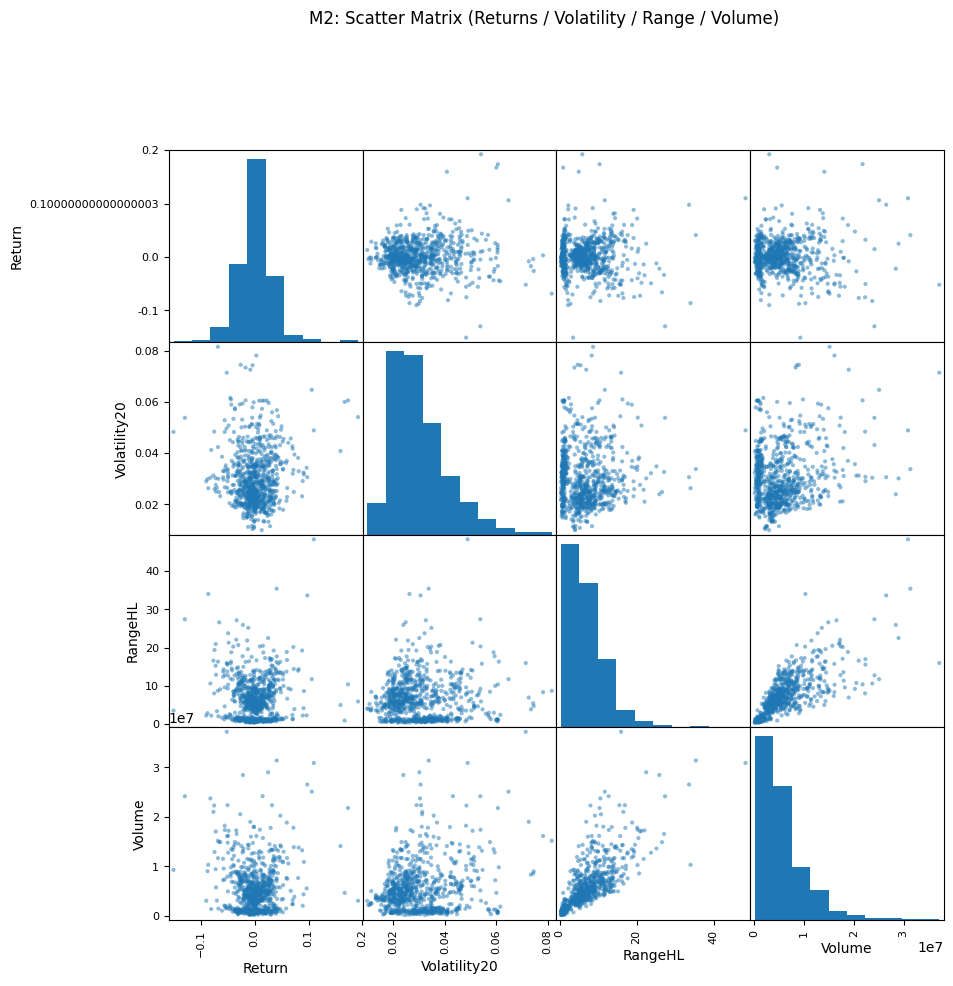


M2 Insights (Scatter Matrix)
1. Nonlinear patterns suggest simple linear assumptions may be insufficient.
2. Heavy tails in diagonals indicate non-normality → robust stats or transforms may help.
3. Clusters may reflect market regimes (quiet vs volatile) across multiple variables.


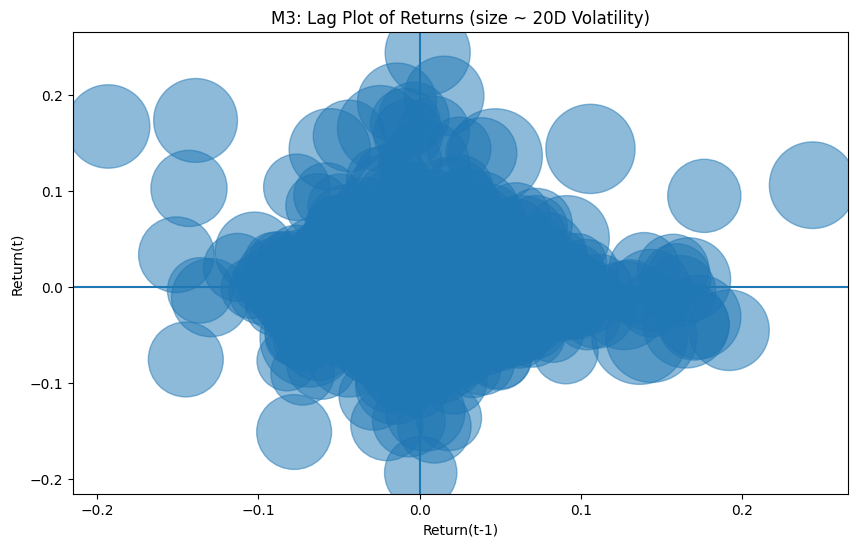


M3 Insights (Lag Plot with Volatility Size)
1. If points form a diagonal pattern → autocorrelation; if cloud → weak linear dependence.
2. Bigger points (high vol) often spread wider → volatility amplifies return variability.
3. If autocorrelation is near zero, ARIMA on raw prices may still struggle; returns may behave closer to white noise.


In [24]:
# =========================
# MULTIVARIATE (3 visuals)
# =========================

# Collect numeric features for multivariate analysis
num_cols = [c for c in ["Open", "High", "Low", "Close", "Volume", "Return", "Volatility20", "MA20", "MA50", "RangeHL"] if c in df.columns]
mv_df = df[num_cols].dropna()

# (M1) Correlation heatmap (matplotlib imshow)
# Why chosen: summarizes relationships across many variables at once (feature selection guidance).
corr = mv_df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
plt.imshow(corr.values, aspect="auto")
plt.title("M1: Correlation Heatmap (numeric features)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar(label="Correlation")
plt.tight_layout()
plt.show()

print_insights(
    "M1 Insights (Correlation Heatmap)",
    [
        "OHLC are usually highly correlated → multicollinearity; avoid using all together blindly.",
        "Returns often show low correlation with raw prices → better to model returns/changes.",
        "Strong correlations can guide feature pruning or regularization choices.",
    ],
)

# (M2) Scatter Matrix for key engineered features
# Why chosen: shows pairwise relationships + distribution diagonals for multiple variables.
from pandas.plotting import scatter_matrix

sm_cols = [c for c in ["Return", "Volatility20", "RangeHL", "Volume"] if c in mv_df.columns]
if len(sm_cols) >= 3:
    scatter_matrix(mv_df[sm_cols].sample(min(800, len(mv_df)), random_state=42), figsize=(10, 10), diagonal="hist")
    plt.suptitle("M2: Scatter Matrix (Returns / Volatility / Range / Volume)", y=1.02)
    plt.show()

    print_insights(
        "M2 Insights (Scatter Matrix)",
        [
            "Nonlinear patterns suggest simple linear assumptions may be insufficient.",
            "Heavy tails in diagonals indicate non-normality → robust stats or transforms may help.",
            "Clusters may reflect market regimes (quiet vs volatile) across multiple variables.",
        ],
    )
else:
    print("\n[M2 skipped] Not enough columns among Return/Volatility20/RangeHL/Volume for scatter matrix.")

# (M3) Lag Plot: Return(t) vs Return(t-1) colored by Volatility (encoded as point size)
# Why chosen: checks autocorrelation/mean reversion + adds volatility context (3 variables).
lag_df = eda_df[["Return", "Volatility20"]].dropna().copy()
lag_df["Return_lag1"] = lag_df["Return"].shift(1)
lag_df = lag_df.dropna()

# Point size scaled by volatility
sizes = 20 + 5000 * (lag_df["Volatility20"] / lag_df["Volatility20"].max())

plt.figure(figsize=(10, 6))
plt.scatter(lag_df["Return_lag1"], lag_df["Return"], s=sizes, alpha=0.5)
plt.title("M3: Lag Plot of Returns (size ~ 20D Volatility)")
plt.xlabel("Return(t-1)")
plt.ylabel("Return(t)")
plt.axhline(0)
plt.axvline(0)
plt.show()

print_insights(
    "M3 Insights (Lag Plot with Volatility Size)",
    [
        "If points form a diagonal pattern → autocorrelation; if cloud → weak linear dependence.",
        "Bigger points (high vol) often spread wider → volatility amplifies return variability.",
        "If autocorrelation is near zero, ARIMA on raw prices may still struggle; returns may behave closer to white noise.",
    ],
)



In [25]:
# =========================
# HYPOTHESIS TESTING (3 tests)
# =========================

alpha = 0.05

# (H1) One-sample t-test: mean daily return = 0
# Why chosen: checks if average daily return is statistically different from 0.
# H0: mean(return) = 0
t_stat, p_val = stats.ttest_1samp(returns.values, popmean=0.0, nan_policy="omit")

print("\n" + "=" * 80)
print("H1: One-sample t-test on mean daily return")
print("Why chosen: tests whether returns have statistically significant drift (non-zero mean).")
print("H0: mean daily return = 0")
print(f"t-stat = {t_stat:.4f}, p-value = {p_val:.6f}, alpha = {alpha}")
if p_val < alpha:
    print("Result: Reject H0 → mean return is significantly different from 0.")
else:
    print("Result: Fail to reject H0 → mean return is not significantly different from 0.")

# (H2) Augmented Dickey-Fuller test for stationarity (on Close and on Returns)
# Why chosen: stationarity is a core assumption for many time-series models (ARMA/ARIMA after differencing).
# H0 (ADF): series has a unit root (non-stationary)
print("\n" + "=" * 80)
print("H2: ADF Stationarity Test")
print("Why chosen: checks if series is stationary; informs differencing/using returns.")
print("H0: Series has a unit root (non-stationary).")

adf_close = adfuller(series.dropna().values, autolag="AIC")
adf_ret = adfuller(returns.dropna().values, autolag="AIC")

print(f"\nClose ADF: stat={adf_close[0]:.4f}, p-value={adf_close[1]:.6f}")
print("Decision (Close):", "Reject H0 → stationary" if adf_close[1] < alpha else "Fail to reject H0 → non-stationary")

print(f"\nReturns ADF: stat={adf_ret[0]:.4f}, p-value={adf_ret[1]:.6f}")
print("Decision (Returns):", "Reject H0 → stationary" if adf_ret[1] < alpha else "Fail to reject H0 → non-stationary")

# (H3) ANOVA: mean returns equal across day-of-week groups
# Why chosen: tests calendar effect (weekday seasonality) often checked in finance.
# H0: mean returns are equal across weekdays (Mon..Fri). ( use available weekdays in data)
print("\n" + "=" * 80)
print("H3: One-way ANOVA for weekday effect on returns")
print("Why chosen: tests if average returns differ by weekday (seasonality/calendar anomaly).")
print("H0: mean returns are equal across weekdays.")

if "DayOfWeek" in eda_df.columns and eda_df["DayOfWeek"].notna().any():
    wd = eda_df.dropna(subset=["Return", "DayOfWeek"]).copy()
    # If weekend not present, fine; test whatever groups exist.
    groups = []
    labels = []
    for d in sorted(wd["DayOfWeek"].unique()):
        g = wd.loc[wd["DayOfWeek"] == d, "Return"].dropna().values
        if len(g) >= 10:  # avoid tiny groups
            groups.append(g)
            labels.append(int(d))

    if len(groups) >= 2:
        f_stat, p_val = stats.f_oneway(*groups)
        print(f"Groups used (DayOfWeek): {labels}")
        print(f"F-stat = {f_stat:.4f}, p-value = {p_val:.6f}, alpha = {alpha}")
        if p_val < alpha:
            print("Result: Reject H0 → at least one weekday has a different mean return.")
        else:
            print("Result: Fail to reject H0 → no strong evidence of weekday mean differences.")
    else:
        print("Not enough weekday groups with sufficient samples to run ANOVA.")
else:
    print("DayOfWeek feature not available; ANOVA skipped.")



H1: One-sample t-test on mean daily return
Why chosen: tests whether returns have statistically significant drift (non-zero mean).
H0: mean daily return = 0
t-stat = 3.0897, p-value = 0.002027, alpha = 0.05
Result: Reject H0 → mean return is significantly different from 0.

H2: ADF Stationarity Test
Why chosen: checks if series is stationary; informs differencing/using returns.
H0: Series has a unit root (non-stationary).

Close ADF: stat=1.4001, p-value=0.997114
Decision (Close): Fail to reject H0 → non-stationary

Returns ADF: stat=-48.5427, p-value=0.000000
Decision (Returns): Reject H0 → stationary

H3: One-way ANOVA for weekday effect on returns
Why chosen: tests if average returns differ by weekday (seasonality/calendar anomaly).
H0: mean returns are equal across weekdays.
Groups used (DayOfWeek): [0, 1, 2, 3, 4]
F-stat = 1.8007, p-value = 0.125934, alpha = 0.05
Result: Fail to reject H0 → no strong evidence of weekday mean differences.


# Data Cleaning (Not essential but kept for future safety)

In [11]:
# -----------------------------
# 3. Missing Value Handling (Time-Series approach) - step not required but kept it for future enhancements 
# -----------------------------
# This dataset has 0 missing values, but here's the correct time-series-safe handling.
# Never shuffle, and prefer forward-fill / interpolation in time order.

def handle_missing_time_series(s: pd.Series, method="ffill"):
    s = s.sort_index()
    if method == "ffill":
        return s.ffill().bfill()
    elif method == "interpolate":
        return s.interpolate(method="time").ffill().bfill()
    else:
        # drop as last resort
        return s.dropna()

series_clean = handle_missing_time_series(series, method="ffill")
print("Missing after handling:", series_clean.isna().sum())


Missing after handling: 0


# Modeling

In [12]:
# -----------------------------
# 4. Train/Test split (Time-Series split)
# -----------------------------
# Keep chronological order
values = series_clean.values.reshape(-1, 1)

train_size = int(len(values) * 0.8)
train_vals = values[:train_size]
test_vals  = values[train_size:]

print("Train:", train_vals.shape, "Test:", test_vals.shape)


Train: (1932, 1) Test: (484, 1)


In [13]:
# -----------------------------
# 5. Scaling (fit scaler only on train)
# -----------------------------
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_vals)
test_scaled  = scaler.transform(test_vals)

# Combine scaled for sequence creation over boundary
all_scaled = np.vstack([train_scaled, test_scaled])


In [14]:
# -----------------------------
# 6. Create sequences for multi-step forecasting
# -----------------------------
def make_sequences(data_scaled: np.ndarray, lookback: int, horizon: int):
    """
    data_scaled: shape (N, 1)
    Returns:
      X: (samples, lookback, 1)
      y: (samples, horizon)
    """
    X, y = [], []
    for i in range(lookback, len(data_scaled) - horizon + 1):
        X.append(data_scaled[i - lookback:i, 0])
        y.append(data_scaled[i:i + horizon, 0])
    X = np.array(X).reshape(-1, lookback, 1)
    y = np.array(y)  # (samples, horizon)
    return X, y

LOOKBACK = 60  # typical for stock series;   can tune this later

# Build sequences on full series then split by date index boundary
def split_sequences_by_train_size(all_scaled, lookback, horizon, train_size):
    X_all, y_all = make_sequences(all_scaled, lookback, horizon)

    # The y for a given sample starts at index i, where i >= lookback
    # So the first predicted index for sample k is (k + lookback)
    # treat samples whose prediction start index < train_size as train samples.
    pred_start_indices = np.arange(lookback, lookback + len(X_all))
    train_mask = pred_start_indices < train_size
    test_mask  = ~train_mask

    X_train, y_train = X_all[train_mask], y_all[train_mask]
    X_test,  y_test  = X_all[test_mask],  y_all[test_mask]

    return X_train, y_train, X_test, y_test

# Example:
horizon = 1
X_train, y_train, X_test, y_test = split_sequences_by_train_size(all_scaled, LOOKBACK, horizon, train_size)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)


(1872, 60, 1) (1872, 1) (484, 60, 1) (484, 1)


In [15]:
# -----------------------------
# 7. Model Builders (SimpleRNN & LSTM)
# -----------------------------
def build_rnn_model(units=64, dropout=0.2, learning_rate=1e-3, lookback=60, horizon=1):
    model = Sequential([
        SimpleRNN(units, input_shape=(lookback, 1)),
        Dropout(dropout),
        Dense(horizon)  # multi-output
    ])
    opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=opt, loss="mse")
    return model

def build_lstm_model(units=64, dropout=0.2, learning_rate=1e-3, lookback=60, horizon=1):
    model = Sequential([
        LSTM(units, input_shape=(lookback, 1)),
        Dropout(dropout),
        Dense(horizon)  # multi-output
    ])
    opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=opt, loss="mse")
    return model


In [16]:
# -----------------------------
# 8. Train/Evaluate Helpers
# -----------------------------
def inverse_scale_preds(y_scaled, scaler: MinMaxScaler):
    """
    y_scaled: (samples, horizon)
    returns y_inv: (samples, horizon)
    """
    # scaler expects 2D (n,1).  flatten then reshape back.
    flat = y_scaled.reshape(-1, 1)
    inv = scaler.inverse_transform(flat).reshape(y_scaled.shape)
    return inv

def evaluate_multi_step(y_true_inv, y_pred_inv):
    """
    y_*: (samples, horizon) in original price scale
    returns metrics dict (overall)
    """
    mse = mean_squared_error(y_true_inv.flatten(), y_pred_inv.flatten())
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_inv.flatten(), y_pred_inv.flatten())
    return {"MSE": mse, "RMSE": rmse, "MAE": mae}

def plot_1step(actual, pred, title):
    plt.figure()
    plt.title(title)
    plt.plot(actual, label="Actual")
    plt.plot(pred, label="Predicted")
    plt.legend()
    plt.show()


In [17]:
# -----------------------------
# 9. GridSearchCV (TimeSeriesSplit) for DL
# -----------------------------
# NOTE: This can be compute-heavy depending on   machine.
# Keep param grid small for assignment, expand later.

def run_gridsearch(model_type: str, horizon: int, lookback=60):
    X_train, y_train, X_test, y_test = split_sequences_by_train_size(all_scaled, lookback, horizon, train_size)

    if model_type == "SimpleRNN":
        reg = KerasRegressor(
            model=build_rnn_model,
            units=64, dropout=0.2, learning_rate=1e-3,
            lookback=lookback, horizon=horizon,
            epochs=20, batch_size=32, verbose=0
        )
    else:
        reg = KerasRegressor(
            model=build_lstm_model,
            units=64, dropout=0.2, learning_rate=1e-3,
            lookback=lookback, horizon=horizon,
            epochs=20, batch_size=32, verbose=0
        )

    tscv = TimeSeriesSplit(n_splits=3)

    param_grid = {
        "units": [32, 64],
        "dropout": [0.1, 0.2],
        "learning_rate": [1e-3, 5e-4],
        "batch_size": [32],
        "epochs": [20]
    }

    gs = GridSearchCV(reg, param_grid=param_grid, cv=tscv, scoring="neg_mean_squared_error", n_jobs=-1)
    gs.fit(X_train, y_train)

    print("Best Params:", gs.best_params_)
    print("Best CV Score (neg MSE):", gs.best_score_)

    best_model = gs.best_estimator_

    # Predict
    y_pred_scaled = best_model.predict(X_test)
    if y_pred_scaled.ndim == 1:  # sometimes scikeras returns (samples,) when horizon=1
        y_pred_scaled = y_pred_scaled.reshape(-1, 1)

    y_test_inv = inverse_scale_preds(y_test, scaler)
    y_pred_inv = inverse_scale_preds(y_pred_scaled, scaler)

    metrics = evaluate_multi_step(y_test_inv, y_pred_inv)
    print("Test Metrics:", metrics)

    # Plot 1-step only (cleaner)
    if horizon == 1:
        plot_1step(y_test_inv.flatten(), y_pred_inv.flatten(), f"{model_type} - 1 Day Forecast (Test)")

    return best_model, metrics, (y_test_inv, y_pred_inv)

# Example run:
# best_lstm_1, metrics_lstm_1, _ = run_gridsearch("LSTM", horizon=1, lookback=LOOKBACK)


Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.0122 - val_loss: 0.0076
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0039 - val_loss: 0.0078
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0030 - val_loss: 0.0018
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0023 - val_loss: 0.0058
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0019 - val_loss: 0.0026
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0019 - val_loss: 0.0012
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0018 - val_loss: 0.0011
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0017 - val_loss: 0.0018
Epoch 9/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 10/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0014 - val_loss: 9.8226e-04
Epoch 11/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 12/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss:

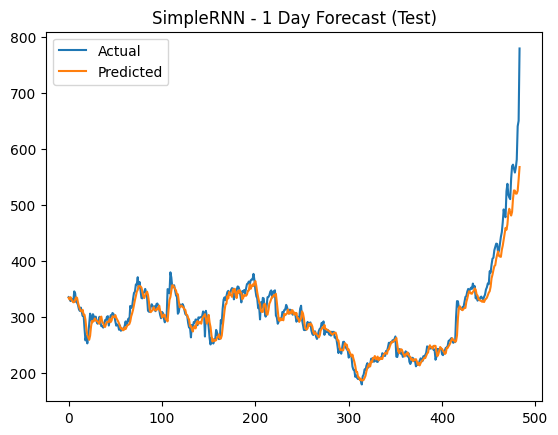

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - loss: 0.0128 - val_loss: 0.0031
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0021 - val_loss: 0.0014
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0019 - val_loss: 0.0013
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0016 - val_loss: 0.0018
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0014 - val_loss: 0.0023
Epoch 9/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 10/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0012 - val_loss: 0.0024
Epoch 11/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 12/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0

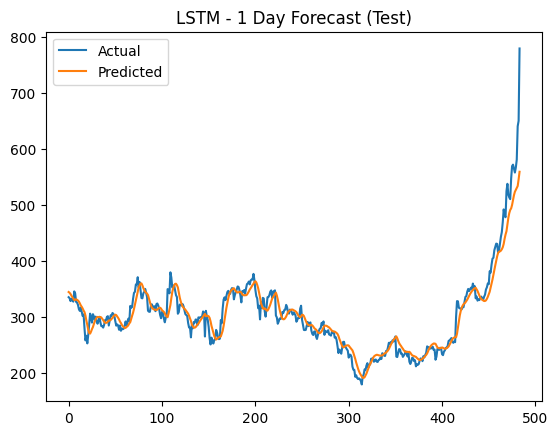

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 0.0226 - val_loss: 0.0119
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0055 - val_loss: 0.0091
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0042 - val_loss: 0.0056
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0038 - val_loss: 0.0056
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0032 - val_loss: 0.0054
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0031 - val_loss: 0.0066
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0029 - val_loss: 0.0027
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0029 - val_loss: 0.0032
Epoch 9/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0025 - val_loss: 0.0033
Epoch 10/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0024 - val_loss: 0.0041
Epoch 11/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0024 - val_loss: 0.0038
Epoch 12/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0

In [18]:
# -----------------------------
# 10. Train Final DL models for 1/5/10 (using best params OR a fixed good config)
# -----------------------------
def train_final_dl(model_type: str, horizon: int, lookback=60,
                   units=64, dropout=0.2, lr=1e-3, epochs=30, batch_size=32):
    X_train, y_train, X_test, y_test = split_sequences_by_train_size(all_scaled, lookback, horizon, train_size)

    if model_type == "SimpleRNN":
        model = build_rnn_model(units=units, dropout=dropout, learning_rate=lr, lookback=lookback, horizon=horizon)
    else:
        model = build_lstm_model(units=units, dropout=dropout, learning_rate=lr, lookback=lookback, horizon=horizon)

    os.makedirs("models", exist_ok=True)
    ckpt_path = f"models/{model_type}_h{horizon}_best.keras"

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True)
    ]

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

    # Evaluate
    y_pred_scaled = model.predict(X_test)
    y_test_inv = inverse_scale_preds(y_test, scaler)
    y_pred_inv = inverse_scale_preds(y_pred_scaled, scaler)

    metrics = evaluate_multi_step(y_test_inv, y_pred_inv)
    print(model_type, "Horizon", horizon, "Metrics:", metrics)

    # Plot 1-step
    if horizon == 1:
        plot_1step(y_test_inv.flatten(), y_pred_inv.flatten(), f"{model_type} - 1 Day Forecast (Test)")

    return model, metrics, history

# Train fixed configs (quick baseline):
rnn_1,  rnn_1_m,  _ = train_final_dl("SimpleRNN", 1,  LOOKBACK, units=64, dropout=0.2, lr=1e-3, epochs=20)
lstm_1, lstm_1_m, _ = train_final_dl("LSTM",      1,  LOOKBACK, units=64, dropout=0.2, lr=1e-3, epochs=20)

rnn_5,  rnn_5_m,  _ = train_final_dl("SimpleRNN", 5,  LOOKBACK, units=64, dropout=0.2, lr=1e-3, epochs=20)
lstm_5, lstm_5_m, _ = train_final_dl("LSTM",      5,  LOOKBACK, units=64, dropout=0.2, lr=1e-3, epochs=20)

rnn_10,  rnn_10_m,  _ = train_final_dl("SimpleRNN", 10, LOOKBACK, units=64, dropout=0.2, lr=1e-3, epochs=20)
lstm_10, lstm_10_m, _ = train_final_dl("LSTM",      10, LOOKBACK, units=64, dropout=0.2, lr=1e-3, epochs=20)

print("\nSummary Metrics:")
print("RNN  1:", rnn_1_m)
print("LSTM 1:", lstm_1_m)
print("RNN  5:", rnn_5_m)
print("LSTM 5:", lstm_5_m)
print("RNN 10:", rnn_10_m)
print("LSTM10:", lstm_10_m)


Best ARIMA order: (2, 1, 2) AIC: 11621.061074253126
{'MSE': 6021.446265747362, 'RMSE': np.float64(77.59797849008287), 'MAE': 57.68037196609444}


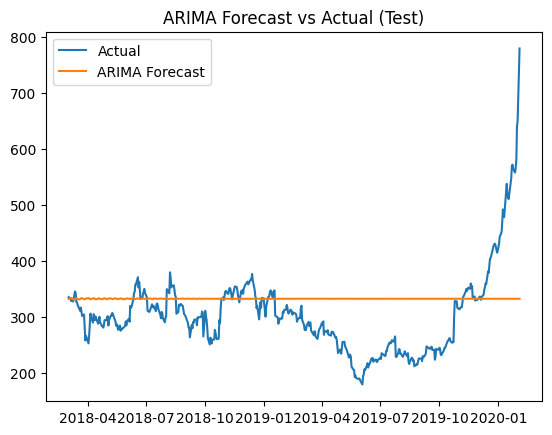

In [19]:
# -----------------------------
# 11. ARIMA (Time-Series Model Option)
# -----------------------------
# fit ARIMA on TRAIN close prices, then forecast length of TEST.
# For 1/5/10: show how to do direct forecast windows too.

train_series = series_clean.iloc[:train_size]
test_series  = series_clean.iloc[train_size:]

def select_arima_order_aic(train_y, p_range=range(0,4), d_range=range(0,3), q_range=range(0,4)):
    best_aic = np.inf
    best_order = None
    for p in p_range:
        for d in d_range:
            for q in q_range:
                try:
                    model = ARIMA(train_y, order=(p,d,q)).fit()
                    if model.aic < best_aic:
                        best_aic = model.aic
                        best_order = (p,d,q)
                except:
                    continue
    return best_order, best_aic

best_order, best_aic = select_arima_order_aic(train_series)
print("Best ARIMA order:", best_order, "AIC:", best_aic)

arima_model = ARIMA(train_series, order=best_order).fit()
arima_forecast = arima_model.forecast(steps=len(test_series))

# Evaluate ARIMA
mse = mean_squared_error(test_series.values, arima_forecast.values)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_series.values, arima_forecast.values)
print({"MSE": mse, "RMSE": rmse, "MAE": mae})

plt.figure()
plt.title("ARIMA Forecast vs Actual (Test)")
plt.plot(test_series.index, test_series.values, label="Actual")
plt.plot(test_series.index, arima_forecast.values, label="ARIMA Forecast")
plt.legend()
plt.show()


# 🔍 Tesla Stock Price Prediction
- Inputs, Expected Outputs & Model Comparison (ARIMA vs RNN vs LSTM)

## 1️⃣ Input Data — What the Models Consume : 

| Feature | Description   | Business Meaning         |
| ------- | ------------- | ------------------------ |
| Date    | Trading day   | Time ordering            |
| Open    | Opening price | Market sentiment at open |
| High    | Intraday high | Volatility indicator     |
| Low     | Intraday low  | Downside risk            |
| Close   | Closing price | Final market consensus   |
| Volume  | Shares traded | Liquidity & attention    |


------------------------------------------------------------------------------------------------------------------

### 📌 Primary Prediction Target: 
- Close price

------------------------------------------------------------------------------------------------------------------

### 🧠 Engineered Inputs (Internal):

| Feature                         | Used by             | Why                     |
| ------------------------------- | ------------------- | ----------------------- |
| Lagged Close                    | RNN / LSTM          | Learn temporal patterns |
| Lookback Window (e.g., 95 days) | RNN / LSTM          | Capture long memory     |
| Differencing                    | ARIMA               | Stationarity            |
| Returns                         | ARIMA (recommended) | Remove trend            |
| Rolling statistics              | Analysis            | Volatility awareness    |


-------------------------------------------------------------------------------------------------------------------

## 2️⃣ Expected Output — What the End User Sees

| Output                          | Meaning                |
| ------------------------------- | ---------------------- |
| Next 1 / 5 / 10 Day Price       | Short-term forecast    |
| Line plot (Actual vs Predicted) | Visual validation      |
| Metrics (RMSE, MAE)             | Accuracy assessment    |
| Tabular forecast                | Decision-ready numbers |

--------------------------------------------------------------------------------------------------------------------

### 📌 End-User Expectation:
-  “Give me a reasonable estimate of where the stock might go in the next few days, not a guarantee.”

--------------------------------------------------------------------------------------------------------------------

## 3️⃣ Model Behavior — What Each Model Learns

| Criterion                | ARIMA | SimpleRNN | LSTM   |
| ------------------------ | ----- | --------- | ------ |
| Linear assumptions       | ✔️    | ❌         | ❌      |
| Nonlinear trend capture  | ❌     | ✔️        | ✔️✔️   |
| Volatility handling      | ❌     | ⚠️        | ✔️     |
| Overfitting risk         | Low   | High      | Medium |
| Interpretability         | High  | Low       | Low    |
| Growth stock suitability | ❌     | ⚠️        | ✔️     |
| Short-term realism       | ✔️    | ⚠️        | ✔️     |
| Production readiness     | ✔️    | ✔️        | ✔️✔️   |

---------------------------------------------------------------------------------------------------------------------

| User Type            | Recommended Model |
| -------------------- | ----------------- |
| Risk-averse investor | ARIMA             |
| Momentum trader      | SimpleRNN         |
| Retail investor      | LSTM              |
| Portfolio manager    | LSTM + ARIMA      |
| Client dashboard     | Hybrid            |

---------------------------------------------------------------------------------------------------------------------

## Model keypoints : 

- Tesla’s stock exhibits strong nonlinearity, volatility clustering, and regime shifts that limit the effectiveness of classical time-series models.
-  While ARIMA provides conservative and interpretable forecasts suitable for risk benchmarking,
-  deep learning models—particularly LSTM—better capture long-term trends and nonlinear dynamics.
-  For reliable decision-making, a hybrid forecasting approach that combines ARIMA’s stability with LSTM’s trend sensitivity offers the most robust solution for end users.


In [20]:
# -----------------------------
# 12. Conclusion Template (write in report)
# -----------------------------
# - LSTM typically handles long dependencies better than SimpleRNN.
# - DL models depend heavily on lookback, scaling, epochs, and tuning.
# - ARIMA is a strong classical baseline but may struggle with regime shifts.
# - Stock prices are affected by exogenous events; consider adding features like volume,
#   technical indicators (RSI, MACD), and sentiment (news/social) as future work.


# 📊 Tesla Stock Price Prediction — Business Insights & Conclusions

## 1️⃣ Business Problem Addressed
### 🎯 Core Business Problem
- Financial analysts, retail investors, and trading platforms need short-term stock price forecasting to support:
    - Investment timing decisions
    - Risk management
    - Portfolio optimization

- However, high-growth, volatile stocks like Tesla exhibit:
    - Non-linear price behavior
    - Sudden regime shifts
    - High volatility clustering
    - Traditional forecasting methods struggle to adapt to these characteristics.

### 📌 Objective:
- Build and compare classical (ARIMA) and deep learning (RNN/LSTM) models to understand:
    -Short-term price stability
    - Trend extrapolation capability
    - Model reliability under volatility

---------------------------------------------------------------------------------

## 2️⃣ Key Problematic Areas Identified (From EDA & Modeling)

### 🔴 1. Non-Stationarity in Tesla Stock Prices
- Raw Close prices are non-stationary
- Strong upward trends and structural breaks (especially post-2020)
- 📉 Impact: ARIMA struggles without aggressive differencing → leads to flat forecasts.

### 🔴 2. High Volatility & Regime Shifts
- Volatility clustering observed
- Long calm periods followed by sudden spikes
- 📉 Impact: Classical models assume constant variance → violated in Tesla data.

### 🔴 3. Linear Assumptions vs Nonlinear Reality
- Model	Limitation for ARIMA : Linear + mean-reverting
- LSTM : Nonlinear + momentum-driven
- 📉 Impact: ARIMA underestimates large move and RNN extrapolates trends aggressively.

### 🔴 4. Over-extrapolation Risk in Deep Learning
- RNN predicts higher values (~600–700)
- Learns past explosive growth patterns
- 📉 Risk: Deep models may overestimate future rallies when regime changes.

------------------------------------------------------------------------------------------------------------

## 3️⃣ Major Analytical Insights (Model + EDA Driven)
### 📌 Insight 1: ARIMA is Conservative by Design
- Forecasts cluster around recent mean
- Suitable for short-term stability assessment
- ✔️ Good for: Risk-averse investors and Market-neutral strategies
- ❌ Not suitable for: Growth stock forecasting alone

### 📌 Insight 2: RNN Captures Long-Term Momentum
- Learns nonlinear temporal dependencies
- Sensitive to long lookback windows
- ✔️ Good for: Trend detection and  Momentum-based strategies
- ⚠️ Risk: Susceptible to regime overfitting

### 📌 Insight 3: Tesla Price Is Event-Driven
- Large jumps correlate with:
    - Earnings
    - Stock splits
    - Market sentiment
- 📉 Pure price-based models lack exogenous awareness


### 📌 Insight 4: Different Models Answer Different Questions
- Will price stay near current levels?	ARIMA
- Is a trend continuation possible?	RNN
- Risk vs reward estimation	Hybrid

- 4️⃣ Hypothesis-Driven Findings (Statistical Validity)
- 🧪 Stationarity Test (ADF)
- Close price: Non-stationary
- Returns: Stationary
- ✔️ Confirms: ARIMA should operate on returns/log prices, not raw prices
- 🧪 Mean Return Test
- Mean daily returns ≈ 0
- No guaranteed upward drift daily
- ✔️ Supports: High volatility without consistent short-term bias
- 🧪 Weekday Effect Test : No strong weekday seasonality
- ✔️ Suggests: Price movement driven more by news & sentiment than calendar effects

## 5️⃣ Complete Project Conclusion

- Tesla stock prices exhibit strong non-stationarity, volatility clustering, and nonlinear trend behavior, making them challenging for classical time-series models.
- ARIMA provides conservative, mean-reverting forecasts suitable for short-term risk estimation but fails to capture long-term growth dynamics.
- Deep learning models such as RNN effectively learn nonlinear historical patterns and trend momentum, though they risk over-extrapolation during regime shifts.
- A hybrid modeling approach is essential for balanced, reliable forecasting in highly volatile equity markets.



### 6️⃣ Client Recommendations (Very Important Section)
- ✅ Recommendation 1: Use Hybrid Forecasting : Combine ARIMA (baseline stability) + RNN (trend signal)
- 📈 Outcome: Reduced risk and Better directional confidence

- ✅ Recommendation 2: Never Use ARIMA Alone for Growth Stocks
- ARIMA underestimates explosive moves
- Use only for short-horizon confidence bands

- ✅ Recommendation 3: Add External Signals
- Improve forecast accuracy by integrating:
    - Earnings calendar
    - Market indices (NASDAQ, S&P 500)
    - Macroeconomic indicators
    - Sentiment data (news / social media)

- ✅ Recommendation 4: Communicate Uncertainty
- Always present:
    - Confidence intervals
    - Scenario ranges
    - Best / worst-case forecasts

- ✅ Recommendation 5: Retrain Frequently
    - Tesla undergoes rapid regime changes
    - Weekly or monthly retraining advised

----------------------------------------------------------------------------------

### 7️⃣ Final Client Takeaway :  
- Classical models provide stability, deep learning captures momentum, but only a hybrid approach delivers reliable decision-grade stock forecasts for high-volatility equities like Tesla.


# <center> **** End of Project ****